### Setup & Installation

In [ ]:
!pip install category_encoders

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV # Import GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE # For handling class imbalance
from imblearn.pipeline import Pipeline # Use imblearn's Pipeline for SMOTE integration
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer # For numerical imputation in pipeline
import category_encoders as ce # For Target Encoding
from sklearn.feature_selection import SelectFromModel # For feature selection based on model importance
from lightgbm import LGBMClassifier
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

In [ ]:
!pip install lightgbm

In [ ]:
!pip install imblearn

In [ ]:
from imblearn.pipeline import Pipeline   # <-- imblearn, not sklearn
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# Load the dataset
url = 'https://drive.google.com/file/d/1-qvcz2XgmaIN6OTz6Uyx4FNFmYWVQncv/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
try:
    df = pd.read_csv(path, encoding="ISO-8859-1")
    df = df.applymap(lambda x: str(x).replace('\xa0', ' ') if isinstance(x, str) else x)
    print("Dataset loaded successfully from Google Drive.")
except Exception as e:
    print(f"Error loading dataset from Google Drive: {e}")
    print("Please ensure the URL is correct and the file is publicly accessible. Exiting as local fallback is removed.")
    exit()

Dataset loaded successfully from Google Drive.


### Data Cleaning & Feature Engineering Part 1

In [ ]:
df_cleaned = df.copy()

In [ ]:
# Remove 13 Duplicate Rows
print("Number of rows:", df_cleaned.shape[0])
print("\nMissing values per column:")
print(df_cleaned.isnull().sum())

Number of rows: 109434

Missing values per column:
Qualifications       26
Employment_Type      27
Age                  19
City                  3
State                 0
Pincode               0
Gender                0
Product_Code          0
Loan_Amount           0
LTV                   0
Resident_Type        19
Net_salary           23
Final_Tier            3
Make_Code             3
Model_Description     3
Model_Variant         3
PAST_LOANS_ACTIVE     0
Decision             12
dtype: int64


In [ ]:
df_cleaned = df.copy()

print("Total number of rows in the dataset:", df_cleaned.shape[0])

print("Step 1: Standardize casing for categorical features")
for col in df_cleaned.select_dtypes(include=['object']).columns:
    if col != 'Decision': # Exclude target column
        df_cleaned[col] = df_cleaned[col].astype(str).str.title().str.strip()

print("Step 2: Remove 13 Duplicate Rows")
print("rows removed:", df_cleaned.duplicated().sum())
df_cleaned.drop_duplicates(inplace=True)
print("Number of rows:", df_cleaned.shape[0])

print("Step 3: Remove 12 NaN in the Decision Variable (Put them in validation set)")
## Create validation_set for rows where decision column is blank
TARGET_COLUMN = 'Decision'
validation_set = df_cleaned[df_cleaned[TARGET_COLUMN].isna()].copy()
print(f"Created validation_set with {len(validation_set)} rows where '{TARGET_COLUMN}' is blank.")
## Handle NaN in target variable in the main dataframe
initial_rows_before_target_nan_check = len(df_cleaned)
if df_cleaned[TARGET_COLUMN].isnull().any():
    print("rows removed:", df_cleaned[TARGET_COLUMN].isnull().sum())
    df_cleaned.dropna(subset=[TARGET_COLUMN], inplace=True)
    print("Number of rows:", df_cleaned.shape[0])

print("Step 4: Fill 20/23 missing City & Final_Tier values (via Pincode) (Excel)")
print("Step 5: Deleted remaining 3 City records")
rows_before = df_cleaned.shape[0]
df_cleaned = df_cleaned.dropna(subset=['City'])
print("rows removed:", rows_before - df_cleaned.shape[0])
print("Number of rows:", df_cleaned.shape[0])

print("Step 6: Fill 23/23 Net_Salary = 0 (as Employment_Type = STU)")
df_cleaned['Net_salary'] = df_cleaned['Net_salary'].fillna(0)
print("Number of rows:", df_cleaned.shape[0])

print("Step 7: Remove 17/17 missing values of Age (missing value for Qualifications, Employment_Type, Resident_Type)")
rows_before = df_cleaned.shape[0]
df_cleaned = df_cleaned.dropna(subset=['Age'])
print("rows removed:", rows_before - df_cleaned.shape[0])
print("Number of rows:", df_cleaned.shape[0])

print("Step 8: Remove 3/3 missing values of Make_Code, Model_Description, Model_Variant (same row)")
rows_before = df_cleaned.shape[0]
df_cleaned = df_cleaned.dropna(subset=['Make_Code', 'Model_Description', 'Model_Variant'])
print("rows removed:", rows_before - df_cleaned.shape[0])
print("Number of rows:", df_cleaned.shape[0])

print("Step 9: Replace 8/8 Employment_Type = 'NA' with 'NON_APP'")
rows_before = (df_cleaned['Employment_Type'] == 'NA').sum()
df_cleaned['Employment_Type'] = df_cleaned['Employment_Type'].replace('NA', 'NON_APP')
print("Number of rows:", df_cleaned.shape[0])

print("Step 10: Remove 7/7 Qualifications missing")
rows_before = df_cleaned.shape[0]
df_cleaned = df_cleaned.dropna(subset=['Qualifications'])
print("rows removed:", rows_before - df_cleaned.shape[0])
print("Number of rows:", df_cleaned.shape[0])

Total number of rows in the dataset: 109434
Step 1: Standardize casing for categorical features
Step 2: Remove 13 Duplicate Rows
rows removed: 13
Number of rows: 109421
Step 3: Remove 12 NaN in the Decision Variable (Put them in validation set)
Created validation_set with 12 rows where 'Decision' is blank.
rows removed: 12
Number of rows: 109409
Step 4: Fill 20/23 missing City & Final_Tier values (via Pincode) (Excel)
Step 5: Deleted remaining 3 City records
rows removed: 0
Number of rows: 109409
Step 6: Fill 23/23 Net_Salary = 0 (as Employment_Type = STU)
Number of rows: 109409
Step 7: Remove 17/17 missing values of Age (missing value for Qualifications, Employment_Type, Resident_Type)
rows removed: 17
Number of rows: 109392
Step 8: Remove 3/3 missing values of Make_Code, Model_Description, Model_Variant (same row)
rows removed: 0
Number of rows: 109392
Step 9: Replace 8/8 Employment_Type = 'NA' with 'NON_APP'
Number of rows: 109392
Step 10: Remove 7/7 Qualifications missing
rows remo

In [ ]:
print("Step 11: Add new column - Model_Price = Loan_Amount * LTV")
df_cleaned['Model_Price'] = df_cleaned['Loan_Amount'] * df_cleaned['LTV']
print("New column 'Model_Price' added.")

print("Step 12: Add new column - Avg_Model_Price (average Model_Price per Model_Description)")
df_cleaned['Avg_Model_Price'] = df_cleaned.groupby('Model_Description')['Model_Price'].transform('mean')
print("New column 'Avg_Model_Price' added.")

print("Step 13: Replace LTV = 0 with correct values (Loan_Amount * 100 / Avg_Model_Price)")
mask = df_cleaned['LTV'] == 0
rows_before = mask.sum()
df_cleaned.loc[mask, 'LTV'] = df_cleaned.loc[mask, 'Loan_Amount'] * 100 / df_cleaned.loc[mask, 'Avg_Model_Price']
print(f"Replaced {rows_before} rows where LTV was 0 with corrected values.")

Step 11: Add new column - Model_Price = Loan_Amount * LTV
New column 'Model_Price' added.
Step 12: Add new column - Avg_Model_Price (average Model_Price per Model_Description)
New column 'Avg_Model_Price' added.
Step 13: Replace LTV = 0 with correct values (Loan_Amount * 100 / Avg_Model_Price)
Replaced 65 rows where LTV was 0 with corrected values.


In [ ]:
print("Number of rows:", df_cleaned.shape[0])
print("\nMissing values per column:")
print(df_cleaned.isnull().sum())

Number of rows: 109392

Missing values per column:
Qualifications       0
Employment_Type      0
Age                  0
City                 0
State                0
Pincode              0
Gender               0
Product_Code         0
Loan_Amount          0
LTV                  0
Resident_Type        0
Net_salary           0
Final_Tier           0
Make_Code            0
Model_Description    0
Model_Variant        0
PAST_LOANS_ACTIVE    0
Decision             0
Model_Price          0
Avg_Model_Price      0
dtype: int64


### Feature Engineering Part 2

In [ ]:
# Create income_presence feature
df_cleaned['Income_Presence'] = 'Income'  # default: income(1)
df_cleaned.loc[(df_cleaned['Employment_Type'] == 'Stu') & (df_cleaned['Net_salary'] == 0), 'Income_Presence'] = 'No Income'  # no income
df_cleaned.loc[(df_cleaned['Employment_Type'] == 'Stu') & (df_cleaned['Net_salary'] > 0), 'Income_Presence'] = 'Guarantor'  # guarantor
df_cleaned.loc[(df_cleaned['Employment_Type'] == 'NON_APP') & (df_cleaned['Net_salary'] == 0), 'Income_Presence'] = 'No Income'
df_cleaned.loc[(df_cleaned['Employment_Type'] == 'NON_APP') & (df_cleaned['Net_salary'] > 0), 'Income_Presence'] = 'Guarantor'
df_cleaned.loc[(df_cleaned['Employment_Type'] == 'Nonearnmem') & (df_cleaned['Net_salary'] == 0), 'Income_Presence'] = 'No Income'
df_cleaned.loc[(df_cleaned['Employment_Type'] == 'Nonearnmem') & (df_cleaned['Net_salary'] > 0), 'Income_Presence'] = 'Guarantor'

In [ ]:
# Binned Numerical Features
if 'Age' in df_cleaned.columns:
    bins_age = [17, 25, 35, 45, 65, 70]
    labels_age = ['18-25', '26-35', '36-45', '46-65', '66-69']
    df_cleaned['Age_Group'] = pd.cut(df_cleaned['Age'], bins=bins_age, labels=labels_age, right=True, include_lowest=True)
    print("New feature 'Age_Group' created by binning Age.")

if 'LTV' in df_cleaned.columns:
    bins_ltv = df_cleaned['LTV'].quantile([0, 0.33, 0.66, 1]).tolist() # Roughly low, medium, high LTV
    bins_ltv[0] = bins_ltv[0] - 1 # Ensure lowest value is included
    labels_ltv = ['LTV_Low', 'LTV_Medium', 'LTV_High']
    df_cleaned['LTV_Band'] = pd.cut(df_cleaned['LTV'], bins=bins_ltv, labels=labels_ltv, include_lowest=True)
    print("New feature 'LTV_Band' created by binning LTV.")

if 'Net_salary' in df_cleaned.columns:
    bins_salary = df_cleaned['Net_salary'].quantile([0, 0.25, 0.5, 0.75, 1]).tolist() # Quartiles
    bins_salary[0] = bins_salary[0] - 1 # Ensure lowest value is included
    labels_salary = ['Low', 'Medium', 'High', 'Very_High']
    df_cleaned['Income_Tier'] = pd.cut(df_cleaned['Net_salary'], bins=bins_salary, labels=labels_salary, include_lowest=True)
    print("New feature 'Income_Tier' created by binning Net_salary.")

if 'Loan_Amount' in df_cleaned.columns:
    bins_loan = df_cleaned['Loan_Amount'].quantile([0, 0.25, 0.5, 0.75, 1]).tolist() # Quartiles
    bins_loan[0] = bins_loan[0] - 1 # Ensure lowest value is included
    labels_loan = ['Low', 'Medium', 'High', 'Very_High']
    df_cleaned['Loan_Amount_Band'] = pd.cut(df_cleaned['Loan_Amount'], bins=bins_loan, labels=labels_loan, include_lowest=True)
    print("New feature 'Loan_Amount_Band' created by binning Loan_Amount.")

New feature 'Age_Group' created by binning Age.
New feature 'LTV_Band' created by binning LTV.
New feature 'Income_Tier' created by binning Net_salary.
New feature 'Loan_Amount_Band' created by binning Loan_Amount.


In [ ]:
# Interaction Features / Advanced Zones
if 'Pincode' in df_cleaned.columns and 'State' in df_cleaned.columns:
    df_cleaned['Pincode_Str'] = df_cleaned['Pincode'].astype(str).str.zfill(6) # Pad with zeros
    df_cleaned['Pincode_Prefix_3'] = df_cleaned['Pincode_Str'].str[:3] # First 3 digits for more granularity
    df_cleaned['State_Pincode_Zone'] = df_cleaned['State'].astype(str) + '_' + df_cleaned['Pincode_Prefix_3'].astype(str)
    print("New feature 'State_Pincode_Zone' created.")

if 'Employment_Type' in df_cleaned.columns and 'Gender' in df_cleaned.columns:
    df_cleaned['Employment_Gender'] = df_cleaned['Employment_Type'].astype(str) + '_' + df_cleaned['Gender'].astype(str)
    print("New feature 'Employment_Gender' created.")

df_cleaned['Income_to_Loan_Ratio'] = df_cleaned.apply(
    lambda row: row['Loan_Amount'] / row['Net_salary'] if row['Net_salary'] > 0 else 0,
    axis=1
)
print("Created 'Income_to_Loan_Ratio'.")

# Calculate the average net salary per state
state_avg_salary = df_cleaned.groupby('State')['Net_salary'].mean().to_dict()
df_cleaned['State_Avg_Salary'] = df_cleaned['State'].map(state_avg_salary)
# You could further create a ratio of individual salary to state average salary
df_cleaned['Salary_vs_State_Avg_Ratio'] = df_cleaned.apply(
    lambda row: row['Net_salary'] / row['State_Avg_Salary'] if row['State_Avg_Salary'] > 0 else 0,
    axis=1
)
print("Created 'State_Avg_Salary' and 'Salary_vs_State_Avg_Ratio'.")

# Handle potential division by zero if Age can be 0 or null, or division by large numbers
df_cleaned['Age_to_Loan_Amount_Ratio'] = df_cleaned.apply(
    lambda row: row['Loan_Amount'] / row['Age'] if row['Age'] > 0 else 0,
    axis=1
)
print("Created 'Age_to_Loan_Amount_Ratio'.")

df_cleaned['PastLoans_Employment_Interaction'] = df_cleaned['PAST_LOANS_ACTIVE'] + '_' + df_cleaned['Employment_Type']
print("Created 'PastLoans_Employment_Interaction'.")

New feature 'State_Pincode_Zone' created.
New feature 'Employment_Gender' created.
Created 'Income_to_Loan_Ratio'.
Created 'State_Avg_Salary' and 'Salary_vs_State_Avg_Ratio'.
Created 'Age_to_Loan_Amount_Ratio'.
Created 'PastLoans_Employment_Interaction'.


In [ ]:
df_cleaned.head()

,Qualifications,Employment_Type,Age,City,State,Pincode,Gender,Product_Code,Loan_Amount,LTV,...,Loan_Amount_Band,Pincode_Str,Pincode_Prefix_3,State_Pincode_Zone,Employment_Gender,Income_to_Loan_Ratio,State_Avg_Salary,Salary_vs_State_Avg_Ratio,Age_to_Loan_Amount_Ratio,PastLoans_Employment_Interaction
0,Ssc,Agr,47.0,Medak,Ap,502110,Male,Mo,59300,69.76,...,Low,502110,502,Ap_502,Agr_Male,1.520513,40447.201371,0.964220,1261.702128,Past_Loans_Active_Agr
1,Ug,Sal,30.0,Gurbabadi,Ap,503002,Male,Mc,153839,84.99,...,Very_High,503002,503,Ap_503,Sal_Male,6.153560,40447.201371,0.618090,5127.966667,Past_Loans_Active_Sal
2,Grad,Nregi,24.0,Nizampet,Ap,500090,Male,Sc,77958,64.97,...,Medium,500090,500,Ap_500,Nregi_Male,2.227371,40447.201371,0.865326,3248.250000,Past_Loans_Active_Nregi
3,Ug,Sal,44.0,Tandur,Ap,501141,Male,Sc,99921,84.68,...,High,501141,501,Ap_501,Sal_Male,3.996840,40447.201371,0.618090,2270.931818,Past_Loans_Active_Sal
4,Ssc,Sal,41.0,Hunwada,Ap,509334,Male,Sc,96482,75.38,...,High,509334,509,Ap_509,Sal_Male,2.756629,40447.201371,0.865326,2353.219512,Past_Loans_Active_Sal


### Model Training & Result

In [ ]:
# Define target variable and features for training
TARGET_COLUMN = 'Decision'
X = df_cleaned.drop(columns=[TARGET_COLUMN, 'Pincode_Str', 'Pincode_Prefix_3', 'City', 'Make_Code', 'Model_Variant', 'Resident_Type', 'Model_Price','Gender']) # Drop temporary Pincode columns and City
y = df_cleaned[TARGET_COLUMN]

# Convert target variable to numerical (0/1)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Invert the encoding: change 0 to 1 and 1 to 0
# If LabelEncoder maps ['APPROVED', 'DECLINED'] to [0, 1],
# then new_encoded = -y_encoded + 1 will map [0, 1] to [1, 0]
y_encoded = -y_encoded + 1
print(f"Target variable mapping: 'APPROVED' -> 1, 'DECLINED' -> 0")


# Identify categorical and numerical features after all feature engineering
numerical_features = X.select_dtypes(include=np.number).columns
categorical_features_all = X.select_dtypes(include=['object', 'category']).columns

# Separate categorical features into low and high cardinality for different encoders
low_cardinality_cols = [col for col in categorical_features_all if X[col].nunique() < 10]
high_cardinality_cols = [col for col in categorical_features_all if X[col].nunique() >= 10]

print(f"\nFinal Numerical features: {list(numerical_features)}")
print(f"Low cardinality categorical features (for OneHotEncoder): {list(low_cardinality_cols)}")
print(f"High cardinality categorical features (for TargetEncoder): {list(high_cardinality_cols)}")

# Create preprocessing pipelines
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Ensure no NaNs before scaling
    ('scaler', StandardScaler()) # Standardize numerical features
])

low_cardinality_transformer = OneHotEncoder(handle_unknown='ignore') # One-hot encode low cardinality features

# Target Encoder: Important to pass the target (y_encoded) during fit for TargetEncoder
high_cardinality_transformer = ce.TargetEncoder(cols=list(high_cardinality_cols), smoothing=0.1)

# Create a column transformer to apply different transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('low_cat', low_cardinality_transformer, low_cardinality_cols),
        ('high_cat', high_cardinality_transformer, high_cardinality_cols)
    ],
    remainder='passthrough' # Keep other columns if any
)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"\nTraining features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Target variable mapping: 'APPROVED' -> 1, 'DECLINED' -> 0

Final Numerical features: ['Age', 'Pincode', 'Loan_Amount', 'LTV', 'Net_salary', 'Avg_Model_Price', 'Income_to_Loan_Ratio', 'State_Avg_Salary', 'Salary_vs_State_Avg_Ratio', 'Age_to_Loan_Amount_Ratio']
Low cardinality categorical features (for OneHotEncoder): ['Qualifications', 'Employment_Type', 'Product_Code', 'Final_Tier', 'PAST_LOANS_ACTIVE', 'Income_Presence', 'Age_Group', 'LTV_Band', 'Income_Tier', 'Loan_Amount_Band']
High cardinality categorical features (for TargetEncoder): ['State', 'Model_Description', 'State_Pincode_Zone', 'Employment_Gender', 'PastLoans_Employment_Interaction']

Training features shape: (87513, 25)
Testing features shape: (21879, 25)
Training target shape: (87513,)
Testing target shape: (21879,)



--- 4. Model Training and Evaluation with LGBMClassifier (Manual Hyperparameter Tuning) ---
Training the LGBM model pipeline...
[LightGBM] [Info] Number of positive: 82675, number of negative: 82675
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.164851 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13714
[LightGBM] [Info] Number of data points in the train set: 165350, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LGBM Model training complete.

Making predictions on the test set...

--- Model Evaluation Metrics ---
Accuracy: 0.9436
Precision: 0.9459
Recall: 0.9974
F1-Score: 0.9710
ROC AUC Score: 0.7661

Confusion Matrix:
[[   30  1179]
 [   54 20616]]


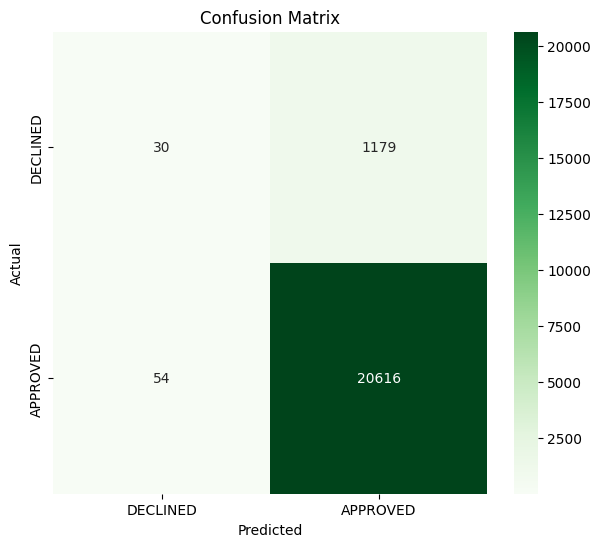


Classification Report:
              precision    recall  f1-score   support

    DECLINED       0.36      0.02      0.05      1209
    APPROVED       0.95      1.00      0.97     20670

    accuracy                           0.94     21879
   macro avg       0.65      0.51      0.51     21879
weighted avg       0.91      0.94      0.92     21879


--- End of Analysis ---


In [ ]:
# --- 4. Model Training and Evaluation with LGBMClassifier (Manual Hyperparameter Tuning) ---
print("\n--- 4. Model Training and Evaluation with LGBMClassifier (Manual Hyperparameter Tuning) ---")

# Define the LGBMClassifier with fixed and manually tunable parameters
# You can change the values of parameters NOT listed in the fixed parameters here
lgbm_model = LGBMClassifier(
    n_estimators=140,
    learning_rate=0.1,
    num_leaves=45,
    objective='binary',
    # metric='binary_logloss',
    metric= ['auc', 'binary_logloss'],  # optimize for AUC, monitor logloss
    random_state=42,
    # --- Manually Tunable Hyperparameters ---
    max_depth=-1, # Example value, change this to explore
    min_child_samples=20, # Example value, change this to explore
    subsample=1.0, # Example value, change this to explore
    colsample_bytree=1.0, # Example value, change this to explore
    reg_alpha=0.0, # Example value, change this to explore
    reg_lambda=0.0, # Example value, change this to explore
    # Add or modify other LGBMClassifier parameters here
)

# Create the full pipeline with preprocessing, SMOTE, and the LGBM classifier
full_pipeline_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)), # Address class imbalance
    ('classifier', lgbm_model)
])

print("Training the LGBM model pipeline...")
# Train the pipeline on the training data
full_pipeline_lgbm.fit(X_train, y_train)
print("LGBM Model training complete.")

# Make predictions on the test set
print("\nMaking predictions on the test set...")
y_pred = full_pipeline_lgbm.predict(X_test)
y_prob = full_pipeline_lgbm.predict_proba(X_test)[:, 1] # Probability of the positive class (APPROVED)

# Evaluate the model
print("\n--- Model Evaluation Metrics ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.figure(figsize=(7, 6))
# Manually set labels based on the inverted encoding (0 for DECLINED, 1 for APPROVED)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['DECLINED', 'APPROVED'],
            yticklabels=['DECLINED', 'APPROVED'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['DECLINED', 'APPROVED']))

print("\n--- End of Analysis ---")

<Figure size 700x600 with 0 Axes>

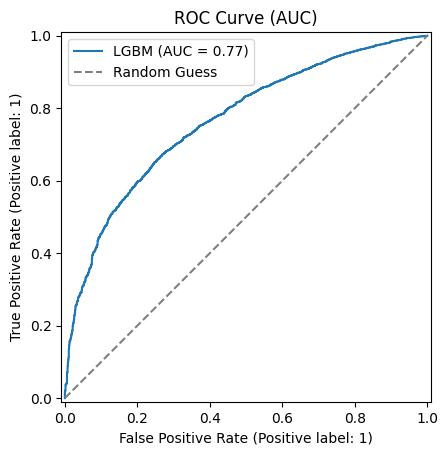

In [ ]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# ROC Curve
plt.figure(figsize=(7,6))
RocCurveDisplay.from_predictions(y_test, y_prob, name="LGBM")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve (AUC)")
plt.legend()
plt.show()

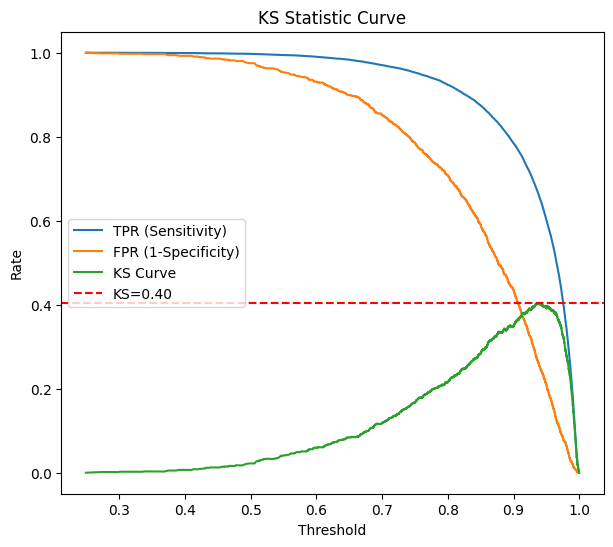

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,6))
plt.plot(thresholds, tpr, label="TPR (Sensitivity)")
plt.plot(thresholds, fpr, label="FPR (1-Specificity)")
plt.plot(thresholds, tpr - fpr, label="KS Curve")
plt.axhline(max(tpr-fpr), color='red', linestyle='--', label=f"KS={max(tpr-fpr):.2f}")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("KS Statistic Curve")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
gini = 2 * roc_auc_score(y_test, y_prob) - 1
print("Gini Coefficient:", gini)

Gini Coefficient: 0.5321046433317607


In [ ]:
from sklearn.metrics import fbeta_score
f2 = fbeta_score(y_test, y_pred, beta=2)
print("F2 Score (Recall weighted):", f2)

F2 Score (Recall weighted): 0.9866475233309404


In [ ]:
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y_test, y_prob)
print("Brier Score:", brier)

Brier Score: 0.05084078943013962


In [ ]:
import numpy as np

def calculate_psi(expected, actual, buckets=10):
    breakpoints = np.arange(0, buckets+1) / buckets
    breakpoints = np.percentile(expected, breakpoints * 100)

    expected_percents = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_percents = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    psi_values = (expected_percents - actual_percents) * np.log((expected_percents + 1e-6) / (actual_percents + 1e-6))
    psi = np.sum(psi_values)
    return psi

psi = calculate_psi(y_train, y_prob)   # Compare train vs test
print("Population Stability Index (PSI):", psi)

Population Stability Index (PSI): 15.733228665733826


Brier Score: 0.05084078943013962


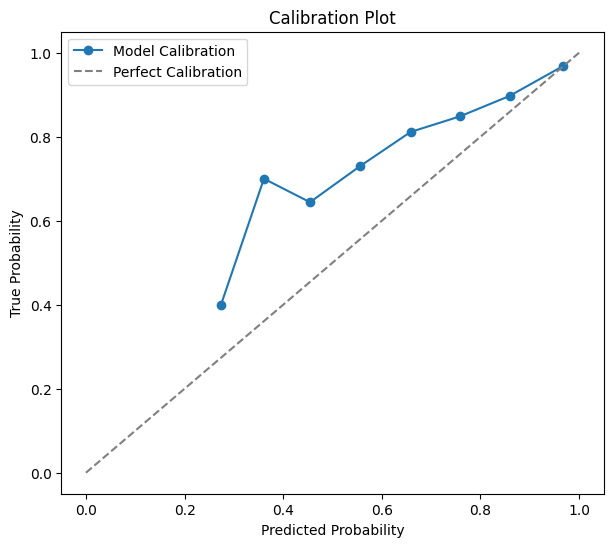

In [ ]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

brier = brier_score_loss(y_test, y_prob)
print("Brier Score:", brier)

# Calibration plot
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(7,6))
plt.plot(prob_pred, prob_true, marker='o', label="Model Calibration")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect Calibration")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Plot")
plt.legend()
plt.show()

In [ ]:
from google.colab import drive
import joblib
import os

# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')
print("Google Drive mounted.")

# Define the base path to your Google Drive
# You might need to adjust this path based on where your dataset is located
# The dataset URL was 'https://drive.google.com/file/d/1IS-Tj90uUldyoK5Zsfxwx2FAnwxtPKm2/view?usp=sharing'
# This suggests the file is in the 'My Drive' folder or a subfolder within it.
# Let's assume the dataset was directly in 'My Drive' or a known subfolder.
# Replace 'My Drive/your_dataset_folder' with the actual folder path if it's not in the root of My Drive
drive_base_path = '/content/drive/MyDrive'

# Define the directory within Google Drive to save the model
# You can choose a specific folder, for example, 'saved_models' within the dataset's folder
# Let's assume the dataset was in a folder named 'LoanPredictionData' for this example.
# Adjust 'LoanPredictionData' to the actual folder name if necessary.
model_save_dir = os.path.join(drive_base_path, 'TW Acquisition')

# Create the directory in Google Drive if it doesn't exist
os.makedirs(model_save_dir, exist_ok=True)
print(f"Ensured model save directory exists in Google Drive: {model_save_dir}")

# Define the full path for the saved model file in Google Drive
model_filename = os.path.join(model_save_dir, 'full_lgbm_pipeline_main.joblib')

# Assuming full_pipeline_lgbm is already trained and available in the environment
if 'full_pipeline_lgbm' in locals():
    print(f"Saving trained model pipeline to Google Drive: {model_filename}")
    # Save the trained pipeline to Google Drive
    joblib.dump(full_pipeline_lgbm, model_filename)
    print("Model pipeline saved successfully to Google Drive.")
else:
    print("Error: Trained model pipeline 'full_pipeline_lgbm' not found in the environment.")
    print("Please ensure the model training cell was executed successfully.")

Mounting Google Drive...
Mounted at /content/drive
Google Drive mounted.
Ensured model save directory exists in Google Drive: /content/drive/MyDrive/TW Acquisition
Saving trained model pipeline to Google Drive: /content/drive/MyDrive/TW Acquisition/full_lgbm_pipeline_main.joblib
Model pipeline saved successfully to Google Drive.


### Chatbot in Colab

In [ ]:
!pip install joblib lightgbm scikit-learn

import joblib
import pandas as pd
import time
from datetime import datetime
from IPython.display import clear_output

In [ ]:
# Adjust path based on where you saved your model
model_path = '/content/drive/MyDrive/TW_Acquisition/full_lgbm_pipeline.joblib'

import joblib
pipeline = joblib.load(model_path)

In [ ]:
print(df_cleaned.columns.tolist())
## dropped - 'Pincode_Str', 'Pincode_Prefix_3', 'City', 'Make_Code', 'Model_Variant', 'Resident_Type'

['Qualifications', 'Employment_Type', 'Age', 'City', 'State', 'Pincode', 'Gender', 'Product_Code', 'Loan_Amount', 'LTV', 'Resident_Type', 'Net_salary', 'Final_Tier', 'Make_Code', 'Model_Description', 'Model_Variant', 'PAST_LOANS_ACTIVE', 'Decision', 'Model_Price', 'Avg_Model_Price', 'Income_Presence', 'Age_Group', 'LTV_Band', 'Income_Tier', 'Loan_Amount_Band', 'Pincode_Str', 'Pincode_Prefix_3', 'State_Pincode_Zone', 'Employment_Gender', 'Income_to_Loan_Ratio', 'State_Avg_Salary', 'Salary_vs_State_Avg_Ratio', 'Age_to_Loan_Amount_Ratio', 'PastLoans_Employment_Interaction']


In [ ]:
# Create lookup dictionaries for dynamic feature generation
# Use .first() to handle non-unique Pincode keys
PINCODE_MAP = df_cleaned.groupby('Pincode')[['State', 'State_Avg_Salary', 'Final_Tier']].first().to_dict('index')
print(len(PINCODE_MAP), "Pincode map created.")

# Group by Make_Code and get unique combinations and average prices
MAKE_CODE_MAP_DF = df_cleaned.groupby(['Make_Code', 'Model_Description', 'Product_Code'])['Loan_Amount'].mean().reset_index()
MAKE_CODE_MAP_DF = MAKE_CODE_MAP_DF.rename(columns={'Loan_Amount': 'Avg_Model_Price'})
MAKE_CODE_MAP = MAKE_CODE_MAP_DF.groupby('Make_Code').apply(
    lambda x: x[['Model_Description', 'Product_Code', 'Avg_Model_Price']].to_dict('records')
).to_dict()
#print(len(MAKE_CODE_MAP_DF), "Make_Code_DF map created.")
print(len(MAKE_CODE_MAP), "Make_Code map created.")

14031 Pincode map created.
13 Make_Code map created.


In [ ]:
import random

# Display random 5 entries of PINCODE_MAP
print("Random 5 entries of PINCODE_MAP:")
random_pincodes = random.sample(list(PINCODE_MAP.items()), min(5, len(PINCODE_MAP)))
for key, value in random_pincodes:
    print(f"{key}: {value}")

print("\nRandom 5 entries of MAKE_CODE_MAP:")
random_make_codes = random.sample(list(MAKE_CODE_MAP.items()), min(5, len(MAKE_CODE_MAP)))
for key, value in random_make_codes:
    print(f"{key}: {value}")

Random 5 entries of PINCODE_MAP:
673010: {'State': 'Kl', 'State_Avg_Salary': 30137.28, 'Final_Tier': '05 Urban'}
683572: {'State': 'Kl', 'State_Avg_Salary': 30137.28, 'Final_Tier': '05 Urban'}
822117: {'State': 'Jh', 'State_Avg_Salary': 29444.04062820075, 'Final_Tier': '06 Semi-Urban'}
466118: {'State': 'Mp', 'State_Avg_Salary': 34512.83985590306, 'Final_Tier': '06 Semi-Urban'}
380060: {'State': 'Gj', 'State_Avg_Salary': 36684.798221614226, 'Final_Tier': '03 Large Metro'}

Random 5 entries of MAKE_CODE_MAP:
Ronin: [{'Model_Description': 'Tvs Ronin 1Ch Base Bsvi', 'Product_Code': 'Mc', 'Avg_Model_Price': 136066.8730964467}, {'Model_Description': 'Tvs Ronin 1Ch Base Plus Bsvi', 'Product_Code': 'Mc', 'Avg_Model_Price': 146130.71666666667}, {'Model_Description': 'Tvs Ronin 2Ch Mid Bsvi', 'Product_Code': 'Mc', 'Avg_Model_Price': 152474.4351851852}, {'Model_Description': 'Tvs Ronin 2Ch Mid Ng Refresh Bsvi', 'Product_Code': 'Mc', 'Avg_Model_Price': 156590.3950617284}, {'Model_Description': 'T

In [ ]:
import json
from google.colab import files

# Save PINCODE_MAP
with open("pincode_map.json", "w") as f:
    json.dump(PINCODE_MAP, f, indent=4)

# Save MAKE_CODE_MAP
with open("make_code_map.json", "w") as f:
    json.dump(MAKE_CODE_MAP, f, indent=4)

# Download both files
files.download("pincode_map.json")
files.download("make_code_map.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Define bin boundaries based on the original dataset for consistency
BINS_AGE = [17, 25, 35, 45, 65, 70]
LABELS_AGE = ['18-25', '26-35', '36-45', '46-65', '66-69']

bins_ltv_calc = df_cleaned['LTV'].quantile([0, 0.33, 0.66, 1]).tolist()
BINS_LTV = [bins_ltv_calc[0] - 1] + bins_ltv_calc[1:]
LABELS_LTV = ['LTV_Low', 'LTV_Medium', 'LTV_High']

bins_salary_calc = df_cleaned['Net_salary'].dropna().quantile([0, 0.25, 0.5, 0.75, 1]).tolist()
BINS_SALARY = [bins_salary_calc[0] - 1] + bins_salary_calc[1:]
LABELS_SALARY = ['Low', 'Medium', 'High', 'Very_High']

bins_loan_calc = df_cleaned['Loan_Amount'].quantile([0, 0.25, 0.5, 0.75, 1]).tolist()
BINS_LOAN = [bins_loan_calc[0] - 1] + bins_loan_calc[1:]
LABELS_LOAN = ['Low', 'Medium', 'High', 'Very_High']
print("Binning parameters calculated.")

def preprocess_applicant_data(applicant_data: dict) -> pd.DataFrame:
    make_code_list = MAKE_CODE_MAP.get(applicant_data['Make_Code'], [])
    if not make_code_list:
        return pd.DataFrame() # Return empty if Make_Code is not found
    applicant_rows = []
    # Check for Pincode existence in map
    pincode_info = PINCODE_MAP.get(applicant_data['Pincode'])
    if not pincode_info:
        print(f"Warning: Pincode {applicant_data['Pincode']} not found in dataset. Skipping...")
        return pd.DataFrame()
    # Check for Net_salary to handle Income_Presence logic
    net_salary_val = applicant_data['Net_salary']
    if applicant_data['Employment_Type'] in ['Stu', 'NON_APP', 'Nonearnmem'] and net_salary_val == 0:
        income_presence = 'No Income'
    elif applicant_data['Employment_Type'] in ['Stu', 'NON_APP', 'Nonearnmem'] and net_salary_val > 0:
        income_presence = 'Guarantor'
    else:
        income_presence = 'Income'
    # Iterate through all combinations for the given Make_Code
    for model_info in make_code_list:
        row_data = applicant_data.copy()
        row_data.update({
            'State': pincode_info['State'],
            'State_Avg_Salary': pincode_info['State_Avg_Salary'],
            'Final_Tier': pincode_info['Final_Tier'],
            'Product_Code': model_info['Product_Code'],
            'Model_Description': model_info['Model_Description'],
            'Avg_Model_Price': model_info['Avg_Model_Price']
        })
        applicant_rows.append(row_data)
    df_processed = pd.DataFrame(applicant_rows)
    # --- Replicate all feature engineering from training pipeline ---
    # Binned Numerical Features
    df_processed['Age_Group'] = pd.cut(df_processed['Age'], bins=BINS_AGE, labels=LABELS_AGE, right=True, include_lowest=True)
    # LTV and LTV_Band
    df_processed['LTV'] = (df_processed['Loan_Amount'] / df_processed['Avg_Model_Price']) * 100 if df_processed['Avg_Model_Price'] > 0 else 0
    df_processed['LTV_Band'] = pd.cut(df_processed['LTV'], bins=BINS_LTV, labels=LABELS_LTV, include_lowest=True)
    df_processed['Income_Tier'] = pd.cut(df_processed['Net_salary'], bins=BINS_SALARY, labels=LABELS_SALARY, include_lowest=True)
    df_processed['Loan_Amount_Band'] = pd.cut(df_processed['Loan_Amount'], bins=BINS_LOAN, labels=LABELS_LOAN, include_lowest=True)
    df_processed['Income_Presence'] = income_presence
    # Interaction Features
    df_processed['Employment_Gender'] = df_processed['Employment_Type'].astype(str) + '_' + df_processed['Gender'].astype(str)
    df_processed['PastLoans_Employment_Interaction'] = df_processed['PAST_LOANS_ACTIVE'].astype(str) + '_' + df_processed['Employment_Type'].astype(str)
    # String manipulation for zones
    df_processed['Pincode_Str'] = df_processed['Pincode'].astype(str).str.zfill(6)
    df_processed['Pincode_Prefix_3'] = df_processed['Pincode_Str'].str[:3]
    df_processed['State_Pincode_Zone'] = df_processed['State'].astype(str) + '_' + df_processed['Pincode'].astype(str)[:3]
    # Ratio features
    df_processed['Income_to_Loan_Ratio'] = df_processed.apply(
        lambda row: row['Loan_Amount'] / row['Net_salary'] if row['Net_salary'] > 0 else 0, axis=1
    )
    df_processed['Age_to_Loan_Amount_Ratio'] = df_processed.apply(
        lambda row: row['Loan_Amount'] / row['Age'] if row['Age'] > 0 else 0, axis=1
    )
    df_processed['Salary_vs_State_Avg_Ratio'] = df_processed.apply(
        lambda row: row['Net_salary'] / row['State_Avg_Salary'] if row['State_Avg_Salary'] > 0 else 0, axis=1
    )

    return df_processed

Binning parameters calculated.


In [ ]:
# Create lookup dictionaries for dynamic feature generation
# Use .first() to handle non-unique Pincode keys
PINCODE_MAP = df_cleaned.groupby('Pincode')[['State', 'State_Avg_Salary', 'Final_Tier']].first().to_dict('index')
print(len(PINCODE_MAP), "Pincode map created.")

# Group by Make_Code and get unique combinations and average prices
MAKE_CODE_MAP_DF = df_cleaned.groupby(['Make_Code', 'Model_Description', 'Product_Code'])['Loan_Amount'].mean().reset_index()
MAKE_CODE_MAP_DF = MAKE_CODE_MAP_DF.rename(columns={'Loan_Amount': 'Avg_Model_Price'})
MAKE_CODE_MAP = MAKE_CODE_MAP_DF.groupby('Make_Code').apply(
    lambda x: x[['Model_Description', 'Product_Code', 'Avg_Model_Price']].to_dict('records')
).to_dict()
#print(len(MAKE_CODE_MAP_DF), "Make_Code_DF map created.")
print(len(MAKE_CODE_MAP), "Make_Code map created.")

# Define bin boundaries based on the original dataset for consistency
BINS_AGE = [17, 25, 35, 45, 65, 70]
LABELS_AGE = ['18-25', '26-35', '36-45', '46-65', '66-69']

bins_ltv_calc = df_cleaned['LTV'].quantile([0, 0.33, 0.66, 1]).tolist()
BINS_LTV = [bins_ltv_calc[0] - 1] + bins_ltv_calc[1:]
LABELS_LTV = ['LTV_Low', 'LTV_Medium', 'LTV_High']

bins_salary_calc = df_cleaned['Net_salary'].dropna().quantile([0, 0.25, 0.5, 0.75, 1]).tolist()
BINS_SALARY = [bins_salary_calc[0] - 1] + bins_salary_calc[1:]
LABELS_SALARY = ['Low', 'Medium', 'High', 'Very_High']

bins_loan_calc = df_cleaned['Loan_Amount'].quantile([0, 0.25, 0.5, 0.75, 1]).tolist()
BINS_LOAN = [bins_loan_calc[0] - 1] + bins_loan_calc[1:]
LABELS_LOAN = ['Low', 'Medium', 'High', 'Very_High']
print("Binning parameters calculated.")

def preprocess_applicant_data(applicant_data: dict) -> pd.DataFrame:
    make_code_list = MAKE_CODE_MAP.get(applicant_data['Make_Code'], [])
    if not make_code_list:
        return pd.DataFrame() # Return empty if Make_Code is not found

    applicant_rows = []

    # Check for Pincode existence in map
    pincode_info = PINCODE_MAP.get(applicant_data['Pincode'])
    if not pincode_info:
        print(f"Warning: Pincode {applicant_data['Pincode']} not found in dataset. Skipping...")
        return pd.DataFrame()

    # Check for Net_salary to handle Income_Presence logic
    net_salary_val = applicant_data['Net_salary']
    if applicant_data['Employment_Type'] in ['Stu', 'NON_APP', 'Nonearnmem'] and net_salary_val == 0:
        income_presence = 'No Income'
    elif applicant_data['Employment_Type'] in ['Stu', 'NON_APP', 'Nonearnmem'] and net_salary_val > 0:
        income_presence = 'Guarantor'
    else:
        income_presence = 'Income'

    # Iterate through all combinations for the given Make_Code
    for model_info in make_code_list:
        row_data = applicant_data.copy()
        row_data.update({
            'State': pincode_info['State'],
            'State_Avg_Salary': pincode_info['State_Avg_Salary'],
            'Final_Tier': pincode_info['Final_Tier'],
            'Product_Code': model_info['Product_Code'],
            'Model_Description': model_info['Model_Description'],
            'Avg_Model_Price': model_info['Avg_Model_Price']
        })
        applicant_rows.append(row_data)

    df_processed = pd.DataFrame(applicant_rows)

    # --- Replicate all feature engineering from training pipeline ---

    # Binned Numerical Features
    df_processed['Age_Group'] = pd.cut(df_processed['Age'], bins=BINS_AGE, labels=LABELS_AGE, right=True, include_lowest=True)

    # LTV and LTV_Band
    # Calculate LTV based on Loan_Amount and Avg_Model_Price for each row
    df_processed['LTV'] = df_processed.apply(
        lambda row: (row['Loan_Amount'] / row['Avg_Model_Price']) * 100 if row['Avg_Model_Price'] > 0 else 0, axis=1
    )
    df_processed['LTV_Band'] = pd.cut(df_processed['LTV'], bins=BINS_LTV, labels=LABELS_LTV, include_lowest=True)

    df_processed['Income_Tier'] = pd.cut(df_processed['Net_salary'], bins=BINS_SALARY, labels=LABELS_SALARY, include_lowest=True)
    df_processed['Loan_Amount_Band'] = pd.cut(df_processed['Loan_Amount'], bins=BINS_LOAN, labels=LABELS_LOAN, include_lowest=True)
    df_processed['Income_Presence'] = income_presence # This should be the same for all rows of the same applicant

    # Interaction Features
    df_processed['Employment_Gender'] = df_processed['Employment_Type'].astype(str) + '_' + df_processed['Gender'].astype(str)
    df_processed['PastLoans_Employment_Interaction'] = df_processed['PAST_LOANS_ACTIVE'].astype(str) + '_' + df_processed['Employment_Type'].astype(str)

    # String manipulation for zones
    df_processed['Pincode_Str'] = df_processed['Pincode'].astype(str).str.zfill(6)
    df_processed['Pincode_Prefix_3'] = df_processed['Pincode_Str'].str[:3]
    df_processed['State_Pincode_Zone'] = df_processed['State'].astype(str) + '_' + df_processed['Pincode'].astype(str)[:3]

    # Ratio features
    df_processed['Income_to_Loan_Ratio'] = df_processed.apply(
        lambda row: row['Loan_Amount'] / row['Net_salary'] if row['Net_salary'] > 0 else 0, axis=1
    )
    df_processed['Age_to_Loan_Amount_Ratio'] = df_processed.apply(
        lambda row: row['Loan_Amount'] / row['Age'] if row['Age'] > 0 else 0, axis=1
    )
    df_processed['Salary_vs_State_Avg_Ratio'] = df_processed.apply(
        lambda row: row['Net_salary'] / row['State_Avg_Salary'] if row['State_Avg_Salary'] > 0 else 0, axis=1
    )

    return df_processed


# --- Chatbot Class ---
class LoanChatbot:
    def __init__(self, model_pipeline):
        self.model_pipeline = model_pipeline
        self.required_questions = [
            {'name': 'Age', 'prompt': 'What is your age? (18-60): ', 'type': int, 'min_val': 18, 'max_val': 60},
            {'name': 'Gender', 'prompt': 'What is your gender? (Male, Female): ', 'type': str, 'valid_options': ['Male', 'Female']},
            {'name': 'Pincode', 'prompt': 'What is your 6-digit pincode? (e.g., 502110): ', 'type': int, 'min_val': 100000, 'max_val': 999999},
            {'name': 'Qualifications', 'prompt': 'What is your highest qualification? (SSC, UG, GRAD, OTHERS, POSTGRAD, PHD, DIP, DIPLOMA, N_A): ', 'type': str, 'valid_options': ['SSC', 'UG', 'GRAD', 'OTHERS', 'POSTGRAD', 'PHD', 'DIP', 'DIPLOMA', 'N_A']},
            {'name': 'Employment_Type', 'prompt': 'What is your employment type? (AGR, SAL, NREGI, SEP, STU, PEN, BUS, OTHERS, GOVT, N_A, Nonearnmem): ', 'type': str, 'valid_options': ['AGR', 'SAL', 'NREGI', 'SEP', 'STU', 'PEN', 'BUS', 'OTHERS', 'GOVT', 'N_A', 'Nonearnmem']},
            {'name': 'Net_salary', 'prompt': 'What is your net monthly salary? (Enter 0 if not applicable): ', 'type': float, 'min_val': 0},
            {'name': 'Make_Code', 'prompt': 'What is the make code of the vehicle? (e.g., MOPEDS, APACHE, JUPITER): ', 'type': str},
            {'name': 'Loan_Amount', 'prompt': 'What is the loan amount you are applying for? (e.g., 90000): ', 'type': int, 'min_val': 10000},
            {'name': 'PAST_LOANS_ACTIVE', 'prompt': 'Do you have any past active loans? (PAST_LOANS_ACTIVE, NO_PAST_LOANS): ', 'type': str, 'valid_options': ['PAST_LOANS_ACTIVE', 'NO_PAST_LOANS']}
        ]
        self.current_applicant_data = {}

    def _get_input(self, prompt_data):
        """Helper to get validated input from the user."""
        prompt = prompt_data['prompt']
        name = prompt_data['name']
        input_type = prompt_data['type']
        valid_options = prompt_data.get('valid_options')
        min_val = prompt_data.get('min_val')
        max_val = prompt_data.get('max_val')

        while True:
            try:
                user_input = input(f"🤖 {prompt}").strip()
                if not user_input:
                    print("Please provide a response.")
                    continue
                if input_type == int:
                    value = int(user_input)
                    if min_val is not None and value < min_val:
                        print(f"Please enter a value greater than or equal to {min_val}.")
                        continue
                    if max_val is not None and value > max_val:
                        print(f"Please enter a value less than or equal to {max_val}.")
                        continue
                elif input_type == float:
                    value = float(user_input)
                    if min_val is not None and value < min_val:
                        print(f"Please enter a value greater than or equal to {min_val}.")
                        continue
                    if max_val is not None and value > max_val:
                        print(f"Please enter a value less than or equal to {max_val}.")
                        continue
                else: # string type
                    value = user_input
                    if valid_options and value not in valid_options:
                        print(f"Invalid option. Please choose from: {', '.join(valid_options)}")
                        continue
                # Special check for Employment_Type and Net_salary
                if name == 'Net_salary' and self.current_applicant_data.get('Employment_Type') in ['Stu', 'NON_APP', 'Nonearnmem']:
                    print("Note: For Students/Non-earners, this amount is considered a Guarantor's income if > 0, otherwise it is 'No Income'.")
                return value
            except ValueError:
                print(f"Invalid input. Please enter a valid {input_type.__name__}.")
            except Exception as e:
                print(f"An unexpected error occurred: {e}")

    def start_conversation(self):
        start_time_total = time.time() # Start total timer
        print("🤖 Welcome to the Loan Application Chatbot!")
        print("I'll ask a few questions to process your loan application.")
        print("Let's get started!\n")

        self.current_applicant_data = {}
        for question in self.required_questions:
            answer = self._get_input(question)
            self.current_applicant_data[question['name']] = answer

            # --- Perform simultaneous feature engineering ---
            if question['name'] == 'Age':
                self.current_applicant_data['Age_Group'] = pd.cut([answer], bins=BINS_AGE, labels=LABELS_AGE, right=True, include_lowest=True)[0]
                print(self.current_applicant_data['Age_Group'])
            #elif question['name'] == 'Gender':
             #   self.current_applicant_data['Employment_Gender'] = f"{self.current_applicant_data['Employment_Type']}_{answer}" if 'Employment_Type' in self.current_applicant_data else 'NA'
            elif question['name'] == 'Pincode':
                pincode_info = PINCODE_MAP.get(answer, {'State': 'NA', 'Final_Tier': 'NA', 'State_Avg_Salary': 'NA'})
                self.current_applicant_data['State'] = pincode_info['State']
                self.current_applicant_data['Final_Tier'] = pincode_info['Final_Tier']
                self.current_applicant_data['State_Avg_Salary'] = pincode_info['State_Avg_Salary']
                self.current_applicant_data['State_Pincode_Zone'] = f"{pincode_info['State']}_{str(answer)[:3]}"
                print(self.current_applicant_data['State'], self.current_applicant_data['Final_Tier'], self.current_applicant_data['State_Avg_Salary'], self.current_applicant_data['State_Pincode_Zone'])
            elif question['name'] == 'Employment_Type':
                self.current_applicant_data['Employment_Gender'] = f"{answer}_{self.current_applicant_data['Gender']}"
                print(self.current_applicant_data['Employment_Gender'])
            elif question['name'] == 'Net_salary':
                self.current_applicant_data['Income_Tier'] = pd.cut([answer], bins=BINS_SALARY, labels=LABELS_SALARY, include_lowest=True)[0]
                if self.current_applicant_data['Employment_Type'] in ['STU', 'NON_APP', 'NONEARNMEM'] and answer > 0:
                    self.current_applicant_data['Income_Presence'] = 'Guarantor'
                elif self.current_applicant_data['Employment_Type'] in ['STU', 'NON_APP', 'NONEARNMEM'] and answer == 0:
                    self.current_applicant_data['Income_Presence'] = 'No Income'
                else:
                    self.current_applicant_data['Income_Presence'] = 'Income'
                if 'State_Avg_Salary' in self.current_applicant_data and self.current_applicant_data['State_Avg_Salary'] > 0:
                    self.current_applicant_data['Salary_vs_State_Avg_Ratio'] = answer / self.current_applicant_data['State_Avg_Salary']
                else:
                    self.current_applicant_data['Salary_vs_State_Avg_Ratio'] = 0
                print(self.current_applicant_data['Income_Tier'], self.current_applicant_data['Income_Presence'],self.current_applicant_data['Salary_vs_State_Avg_Ratio'])

            elif question['name'] == 'Loan_Amount':
                self.current_applicant_data['Loan_Amount_Band'] = pd.cut([answer], bins=BINS_LOAN, labels=LABELS_LOAN, include_lowest=True)[0]
                if self.current_applicant_data['Net_salary'] > 0:
                    self.current_applicant_data['Income_to_Loan_Ratio'] = answer / self.current_applicant_data['Net_salary']
                else:
                    self.current_applicant_data['Income_to_Loan_Ratio'] = 0
                if self.current_applicant_data['Age'] > 0:
                    self.current_applicant_data['Age_to_Loan_Amount_Ratio'] = answer / self.current_applicant_data['Age']
                else:
                    self.current_applicant_data['Age_to_Loan_Amount_Ratio'] = 0
                print(self.current_applicant_data['Loan_Amount_Band'], self.current_applicant_data['Income_to_Loan_Ratio'],self.current_applicant_data['Age_to_Loan_Amount_Ratio'])
            elif question['name'] == 'PAST_LOANS_ACTIVE':
                self.current_applicant_data['PastLoans_Employment_Interaction'] = f"{answer}_{self.current_applicant_data['Employment_Type']}"
                print(self.current_applicant_data['PastLoans_Employment_Interaction'])
            print("-" * 30)
        print("\nThank you for providing the information!")
        print("Evaluating all eligible vehicle models for your loan...")

        # --- Real-time Decisioning ---
        start_time_processing = time.time() # Start processing timer
        try:
            # 1. Dynamically generate the data
            processed_df = preprocess_applicant_data(self.current_applicant_data)

            if processed_df.empty:
                print("Sorry, no valid models could be found for the provided Make Code or Pincode.")
                print("Please try again with different inputs.")
                return

            # 2. Make predictions for all generated rows
            prediction_probas = self.model_pipeline.predict_proba(processed_df)
            predictions = pd.DataFrame(prediction_probas, columns=['Decline_Prob', 'Approve_Prob'])

            # Combine predictions with original info to display to user
            results_df = pd.concat([processed_df[['Make_Code', 'Model_Description', 'Avg_Model_Price', 'Product_Code']], predictions], axis=1)
            results_df = pd.concat([processed_df[['Make_Code', 'Model_Description', 'Avg_Model_Price', 'Product_Code']], predictions], axis=1)

            # Define approval threshold
            DECISION_THRESHOLD = 0.5
            approved_models = results_df[results_df['Approve_Prob'] >= DECISION_THRESHOLD]

            # 3. Present the decision
            if not approved_models.empty:
                print("\n--- 🎉 Congratulations! Your loan is APPROVED for the following models: ---")
                approved_models_list = approved_models[['Make_Code', 'Model_Description']].to_string(index=False)
                print(approved_models_list)
                print("\nNext steps: We will send the loan agreement for these models to your email.")
            else:
                print("\n--- 😔 Loan Application Status ---")
                print("We regret to inform you that your application is not eligible for a loan with the provided details.")
                print("Please contact our customer support at XX for more assistance.")

        except Exception as e:
            error_message = f"An error occurred during prediction: {e}"
            print(f"\n--- Error ---")
            print(error_message)

        end_time_processing = time.time() # End processing timer
        processing_time = end_time_processing - start_time_processing
        print(f"\nProcessing and Prediction Time: {processing_time:.2f} seconds")

        end_time_total = time.time() # End total timer
        total_time = end_time_total - start_time_total
        print(f"Total Chatbot Session Time: {total_time:.2f} seconds")

        print("\n--- Chat Session Ended ---")
        print("Thank you for using our chatbot!")


# --- Main Execution ---
if __name__ == "__main__":
    chatbot = LoanChatbot(pipeline)
    chatbot.start_conversation()

14031 Pincode map created.
13 Make_Code map created.
Binning parameters calculated.
🤖 Welcome to the Loan Application Chatbot!
I'll ask a few questions to process your loan application.
Let's get started!

🤖 What is your age? (18-60): 34
26-35
------------------------------
🤖 What is your gender? (Male, Female): Female
------------------------------
🤖 What is your 6-digit pincode? (e.g., 502110): 110003
Dl 01 Megapolis (A) 35699.225173210165 Dl_110
------------------------------
🤖 What is your highest qualification? (SSC, UG, GRAD, OTHERS, POSTGRAD, PHD, DIP, DIPLOMA, N_A): UG
------------------------------
🤖 What is your employment type? (AGR, SAL, NREGI, SEP, STU, PEN, BUS, OTHERS, GOVT, N_A, Nonearnmem): STU
STU_Female
------------------------------
🤖 What is your net monthly salary? (Enter 0 if not applicable): 56000
Very_High Guarantor 1.5686614969454347
------------------------------
🤖 What is the make code of the vehicle? (e.g., MOPEDS, APACHE, JUPITER): Apache
-----------------